In [173]:
import json
from collections import Counter
import matplotlib.pyplot as plt
%matplotlib inline

In [174]:
exercises = {}
with open("clean_exercises.json",'r',encoding='utf-8') as file:
    exercises = json.load(file)

print(len(exercises))

1324


In [150]:
categories = sorted({e["category"] for e in exercises})
categories_count = dict(Counter(e["category"] for e in exercises))
print(categories)
print(categories_count)

['back', 'cardio', 'chest', 'lower arms', 'lower legs', 'neck', 'shoulders', 'upper arms', 'upper legs', 'waist']
{'waist': 169, 'upper legs': 227, 'back': 203, 'lower legs': 59, 'chest': 163, 'upper arms': 292, 'cardio': 29, 'shoulders': 143, 'lower arms': 37, 'neck': 2}


In [151]:
equipments = sorted({e["equipment"] for e in exercises})
equipments_count = dict(Counter(e["equipment"] for e in exercises))
print(equipments)
print(equipments_count)

['assisted', 'band', 'barbell', 'body weight', 'bosu ball', 'cable', 'dumbbell', 'elliptical machine', 'ez barbell', 'hammer', 'kettlebell', 'leverage machine', 'medicine ball', 'olympic barbell', 'resistance band', 'roller', 'rope', 'skierg machine', 'sled machine', 'smith machine', 'stability ball', 'stationary bike', 'stepmill machine', 'tire', 'trap bar', 'upper body ergometer', 'weighted', 'wheel roller']
{'body weight': 325, 'cable': 157, 'leverage machine': 81, 'assisted': 15, 'medicine ball': 13, 'stability ball': 28, 'band': 54, 'barbell': 154, 'rope': 10, 'dumbbell': 294, 'ez barbell': 23, 'sled machine': 15, 'upper body ergometer': 1, 'kettlebell': 41, 'olympic barbell': 2, 'weighted': 36, 'bosu ball': 3, 'resistance band': 7, 'roller': 8, 'skierg machine': 1, 'hammer': 1, 'smith machine': 48, 'wheel roller': 2, 'stationary bike': 1, 'tire': 1, 'trap bar': 1, 'elliptical machine': 1, 'stepmill machine': 1}


In [152]:
target = sorted({e["target"] for e in exercises})
target_count = dict(Counter(e["target"] for e in exercises))
print(categories)
print(target_count)

['back', 'cardio', 'chest', 'lower arms', 'lower legs', 'neck', 'shoulders', 'upper arms', 'upper legs', 'waist']
{'abs': 169, 'quads': 44, 'lats': 81, 'calves': 59, 'pectorals': 158, 'glutes': 144, 'hamstrings': 28, 'adductors': 6, 'triceps': 141, 'cardiovascular system': 29, 'spine': 19, 'upper back': 88, 'biceps': 151, 'delts': 143, 'forearms': 37, 'traps': 15, 'serratus anterior': 5, 'abductors': 5, 'levator scapulae': 2}


## Visualization

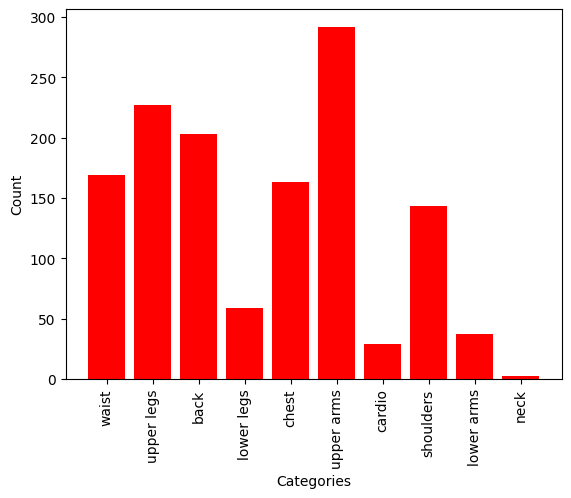

In [153]:
plt.bar(categories_count.keys(),categories_count.values(),color="r")
plt.xlabel("Categories")
plt.xticks(rotation="vertical")
plt.ylabel("Count")
plt.show()

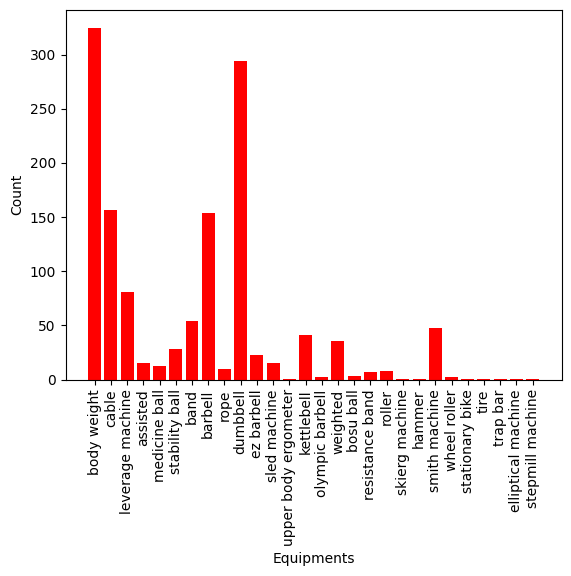

In [154]:
plt.bar(equipments_count.keys(),equipments_count.values(),color="r")
plt.xlabel("Equipments")
plt.xticks(rotation="vertical")
plt.ylabel("Count")
plt.show()

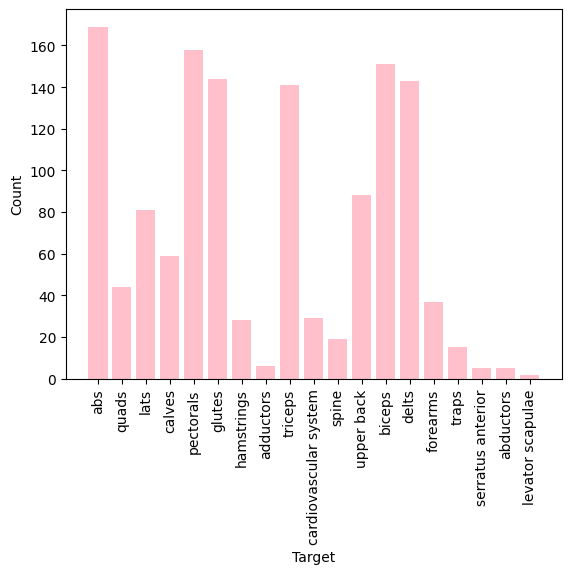

In [155]:
plt.bar(target_count.keys(),target_count.values(),color="pink")
plt.xlabel("Target")
plt.xticks(rotation="vertical")
plt.ylabel("Count")
plt.show()

In [156]:
def filter_category(exercises,category):
    filtered = []

    for exercise in exercises:
        if exercise["category"].lower() == category:
            filtered.append(exercise)

    return filtered

In [157]:
# print(exercises)
filtered_exercises = filter_category(exercises,"shoulders")
for exercise in filtered_exercises[:5]:
    print(exercise)

{'id': '0977', 'name': 'band front lateral raise', 'category': 'shoulders', 'body_part': 'shoulders', 'equipment': 'band', 'instruction_steps': ['Stand with your feet shoulder-width apart and hold the band in front of your thighs with your palms facing down.', 'Keep your arms straight and lift the band up in front of you until your arms are parallel to the ground.', 'Pause for a moment at the top, then slowly lower the band back down to the starting position.', 'Repeat for the desired number of repetitions.'], 'muscle_group': 'traps', 'secondary_muscles': ['traps', 'upper back'], 'target': 'delts', 'gif_url': 'videos/0977-sTg7iys.gif'}
{'id': '0978', 'name': 'band front raise', 'category': 'shoulders', 'body_part': 'shoulders', 'equipment': 'band', 'instruction_steps': ['Stand with your feet shoulder-width apart and hold the band in front of your thighs with your palms facing down.', 'Keep your arms straight and slowly raise them forward until they are parallel to the ground.', 'Pause 

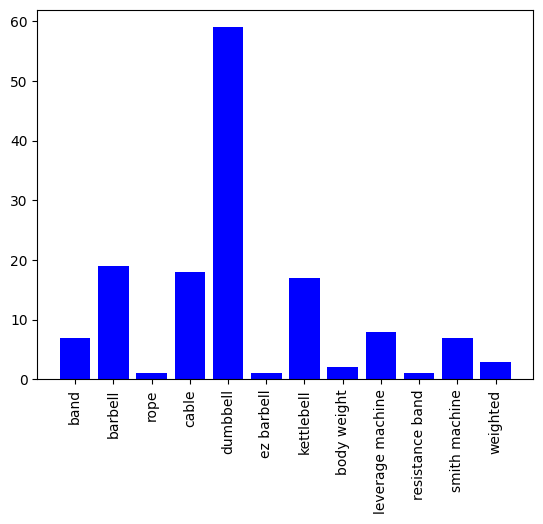

In [158]:
from collections import Counter

equipment_count = dict(Counter(
    exercise["equipment"]
    for exercise in filtered_exercises
))

plt.bar(equipment_count.keys(),equipment_count.values(),color='b')
plt.xticks(rotation="vertical")
plt.show()

In [159]:
from collections import defaultdict

equipment_groups = defaultdict(list)

for exercise in filtered_exercises:
    equipment_groups[exercise["equipment"]].append(exercise)

equipment_groups

defaultdict(list,
            {'band': [{'id': '0977',
               'name': 'band front lateral raise',
               'category': 'shoulders',
               'body_part': 'shoulders',
               'equipment': 'band',
               'instruction_steps': ['Stand with your feet shoulder-width apart and hold the band in front of your thighs with your palms facing down.',
                'Keep your arms straight and lift the band up in front of you until your arms are parallel to the ground.',
                'Pause for a moment at the top, then slowly lower the band back down to the starting position.',
                'Repeat for the desired number of repetitions.'],
               'muscle_group': 'traps',
               'secondary_muscles': ['traps', 'upper back'],
               'target': 'delts',
               'gif_url': 'videos/0977-sTg7iys.gif'},
              {'id': '0978',
               'name': 'band front raise',
               'category': 'shoulders',
               'body

In [160]:
for equipment, exercises in equipment_groups.items():
    print(f"{equipment}: {len(exercises)}")

band: 7
barbell: 19
rope: 1
cable: 18
dumbbell: 59
ez barbell: 1
kettlebell: 17
body weight: 2
leverage machine: 8
resistance band: 1
smith machine: 7
weighted: 3


In [161]:
for exercise in equipment_groups["body weight"][:10]:
    print(exercise["name"])

left hook. boxing
rear deltoid stretch


In [162]:
from collections import Counter

target_count = Counter(
    exercise["target"]
    for exercise in equipment_groups["body weight"]
)

print(target_count)

Counter({'delts': 2})


In [175]:
from collections import defaultdict, Counter

# Filter shoulders exercises
filtered_exercises = filter_category(exercises, "shoulders")

# Group by equipment
equipment_groups = defaultdict(list)

for exercise in filtered_exercises:
    equipment_groups[exercise["equipment"]].append(exercise)

# Print target distribution for each equipment
for equipment in equipment_groups:

    print(f"\n===== {equipment.upper()} =====")

    target_count = Counter(
        exercise["target"]
        for exercise in equipment_groups[equipment]
    )

    print(target_count)


===== BAND =====
Counter({'delts': 7})

===== BARBELL =====
Counter({'delts': 19})

===== ROPE =====
Counter({'delts': 1})

===== CABLE =====
Counter({'delts': 18})

===== DUMBBELL =====
Counter({'delts': 59})

===== EZ BARBELL =====
Counter({'delts': 1})

===== KETTLEBELL =====
Counter({'delts': 17})

===== BODY WEIGHT =====
Counter({'delts': 2})

===== LEVERAGE MACHINE =====
Counter({'delts': 8})

===== RESISTANCE BAND =====
Counter({'delts': 1})

===== SMITH MACHINE =====
Counter({'delts': 7})

===== WEIGHTED =====
Counter({'delts': 3})


In [176]:
import random

for equipment in equipment_groups:
    random.shuffle(equipment_groups[equipment])

In [177]:
for exercise in equipment_groups["dumbbell"][:5]:
    print(exercise["name"])

dumbbell standing around world
dumbbell rear delt row_shoulder
dumbbell one arm shoulder press v. 2
dumbbell rear lateral raise (support head)
dumbbell iron cross


In [178]:
COMMON = [
    "body weight",
    "dumbbell",
    "barbell",
    "cable",
    "band"
]

In [ ]:
workout = []

while len(workout) < 10:

    added = False

    for equipment in COMMON:
        print(equipment, len(equipment_groups.get(equipment, [])))
        if equipment in equipment_groups and equipment_groups[equipment]:

            workout.append(equipment_groups[equipment].pop(0))
            added = True

            if len(workout) == 10:
                break

    if not added:
        break

    

body weight 0
dumbbell 54
barbell 14
cable 14
band 3
body weight 0
dumbbell 53
barbell 13
cable 13
band 2
body weight 0
dumbbell 52
barbell 12


In [ ]:
special = []

for equipment, exercises in equipment_groups.items():
    if equipment not in COMMON:
        special.extend(exercises)

In [183]:
print(workout)

[{'id': '0360', 'name': 'dumbbell one arm shoulder press v. 2', 'category': 'shoulders', 'body_part': 'shoulders', 'equipment': 'dumbbell', 'instruction_steps': ['Stand with your feet shoulder-width apart and hold a dumbbell in one hand at shoulder level, palm facing forward.', 'Engage your core and press the dumbbell straight up overhead, fully extending your arm.', 'Pause for a moment at the top, then slowly lower the dumbbell back to shoulder level.', 'Repeat for the desired number of repetitions, then switch to the other arm.'], 'muscle_group': 'triceps', 'secondary_muscles': ['triceps', 'upper back'], 'target': 'delts', 'gif_url': 'videos/0360-1TkiAFK.gif'}, {'id': '3305', 'name': 'barbell thruster', 'category': 'shoulders', 'body_part': 'shoulders', 'equipment': 'barbell', 'instruction_steps': ['Start by standing with your feet shoulder-width apart, holding a barbell at shoulder height with an overhand grip.', 'Lower into a squat position by bending your knees and pushing your hi